In [6]:
using JLD
using Plots
using LaTeXStrings
using Random
RNG = Xoshiro(1)

include("samplers.jl")
# include("coupled_stereo_mrw_meeting_times.jl")


coupled_MH_step! (generic function with 1 method)

In [7]:
# target distribution
d::Int64 = 2
ν::Int64 = d + 10
log_density(x) = ((ν + d)/2) * log(1 + dot(x,x)/ν)


log_density (generic function with 1 method)

In [8]:
# tuning parameters
h::Float64 = 0.01
R = 1.0

1.0

In [9]:
# initialize the chain
x = normalize(randn(RNG, d+1))
G = randn(RNG, d+1);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


Acceptance rate: 0.998


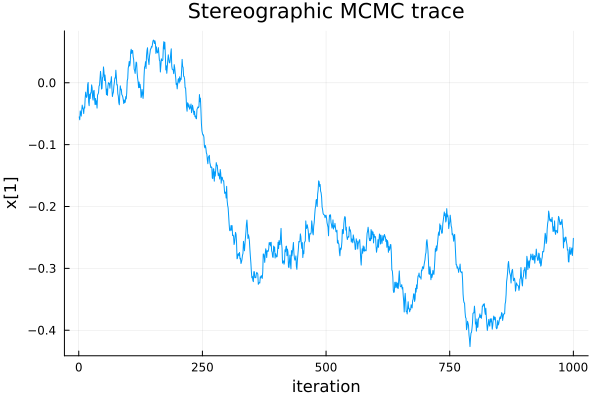

In [10]:
using ProgressMeter

R = 1.0
x_prop = copy(x)
n_steps = 1000
trajectory = zeros(n_steps, d+1)
n_accepted = 0

@showprogress for i in 1:n_steps
    randn!(RNG, G)
    x_prop .= x
    x1_before = x[1]
    stereo_MH_step!(x, x_prop, G, h, d, R, log_density, RNG)
    n_accepted += x[1] != x1_before
    trajectory[i, :] .= x
end

println("Acceptance rate: ", round(n_accepted / n_steps, digits=3))
plot(trajectory[:, 1], xlabel="iteration", ylabel="x[1]", title="Stereographic MCMC trace", legend=false)

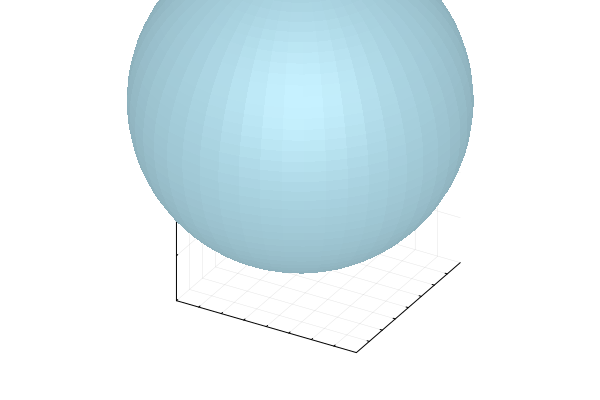

print device already activated


In [14]:
# Sphere surface
θ = range(0, π, length=50)
φ = range(0, 2π, length=50)
sx = [sin(t) * cos(p) for t in θ, p in φ]
sy = [sin(t) * sin(p) for t in θ, p in φ]
sz = [cos(t)          for t in θ, p in φ]

surface(sx, sy, sz, alpha=0.15, color=:lightblue, colorbar=false, label=false)
# plot3d!(trajectory[:, 1], trajectory[:, 2], trajectory[:, 3],
#         linewidth=1, color=:red, label="trajectory",
#         xlabel="x₁", ylabel="x₂", zlabel="x₃",
#         title="MCMC trajectory on S²")
# scatter3d!([trajectory[1, 1]], [trajectory[1, 2]], [trajectory[1, 3]],
#            color=:green, markersize=5, label="start")